In [2]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
conn = sqlite3.connect('C:/Users/RISHAV/OneDrive/Desktop/Python/Project 10-Invoice Intelligent System/data/inventory.db')

In [42]:
tables = pd.read_sql_query('select name from sqlite_master where type="table"',conn)

In [43]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [44]:
for table in tables['name']:
    print('Table name:', table)
    df = pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [45]:
#predicting freight cost using vendor invoice data
vendor_df = pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df.sample(5)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
3215,1128,BROWN-FORMAN CORP,2024-08-08,11382,2024-07-27,2024-09-23,17843,239908.07,1127.57,NaN
913,1590,DIAGEO CHATEAU ESTATE WINES,2024-03-15,9097,2024-02-26,2024-04-21,1923,15325.04,68.96,NaN
1736,12546,JIM BEAM BRANDS COMPANY,2024-05-04,9907,2024-04-22,2024-06-17,49749,498593.97,2343.39,Frank Delahunt
868,8150,SEA HAGG DISTILLERY LLC,2024-03-06,8957,2024-02-16,2024-04-14,130,1729.42,8.65,NaN
4903,90024,VINILANDIA USA,2024-11-25,13026,2024-11-11,2025-01-06,1060,12030.56,62.56,NaN


In [46]:
vendor_df[['Quantity', 'Dollars', 'Freight']].corr()

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


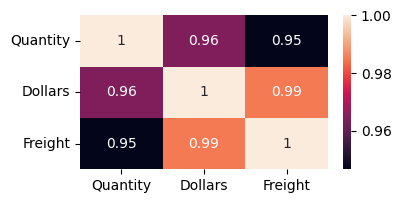

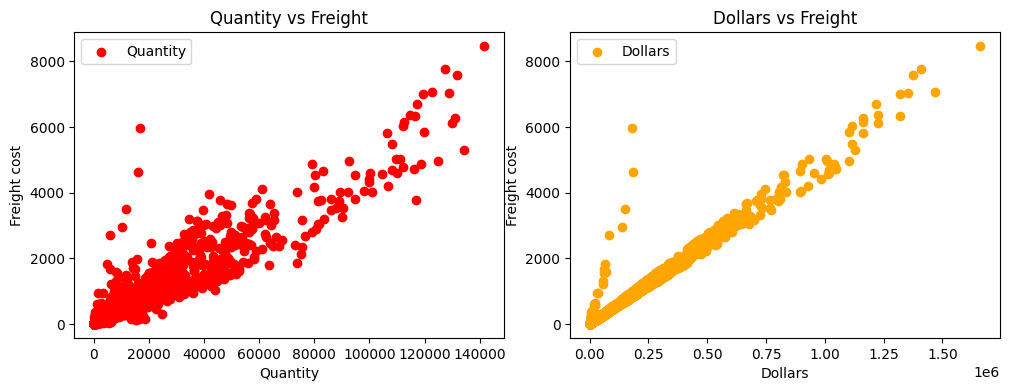

In [47]:
plt.figure(figsize=(4, 2))
sns.heatmap(vendor_df[['Quantity', 'Dollars', 'Freight']].corr(), annot=True ,color = 'blue')
plt.show()


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].scatter(vendor_df['Quantity'], vendor_df['Freight'], color='red')
axes[0].set_title('Quantity vs Freight')

axes[1].scatter(vendor_df['Dollars'], vendor_df['Freight'], color='orange')
axes[1].set_title('Dollars vs Freight')

plt.tight_layout()

axes[0].legend(['Quantity'])
axes[1].legend(['Dollars'])

axes[0].set_ylabel('Freight cost')
axes[0].set_xlabel('Quantity')

axes[1].set_ylabel('Freight cost')
axes[1].set_xlabel('Dollars')

plt.show()

From the above analysis we can conclude that both quanity and dollars have strong relation with freight cost but Quantity has maximum correlation with freight cost, so we will use Quantity, not both because there will be a chance of multcollinearity

In [48]:
vendor_df['Freight_cost_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity'] # 1 unit ke liye vendor kitna freight cost pay kar rha hai
vendor_df


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,Freight_cost_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,NaN,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,NaN,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,NaN,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,NaN,0.033117


In [49]:
vendor_df['Quantity'].describe()

count      5543.000000
mean       6058.880931
std       14453.338164
min           1.000000
25%          83.000000
50%         423.000000
75%        5100.500000
max      141660.000000
Name: Quantity, dtype: float64

- Vendor ka highest quantity hai 5100 
- vendor ka lowest quantity hai 83

In [50]:
# I need to filter out freight cost with the lowest quatity and the highest quantity to get a better understanding of the freight cost per unit.

#freight cost with lowest quantity
vendor_df.loc[vendor_df['Quantity'] < vendor_df['Quantity'].quantile(0.25), 'Freight_cost_per_unit'].mean()

np.float64(0.09489854253138316)

In [51]:
#freight cost with highest quantity
vendor_df.loc[vendor_df['Quantity'] > vendor_df['Quantity'].quantile(0.75), 'Freight_cost_per_unit'].mean()

np.float64(0.049077654690759046)

Conclusion - if a vendor order in bulk, it needs to pay less, and if the buy less quantity they need to pay more

In [66]:
# from sklearn.preprocessing import RobustScaler

# rs = RobustScaler()
# X_scaled_data = rs.fit_transform(vendor_df[['Quantity', 'Dollars']])
# y_scaled_data = rs.fit_transform(vendor_df[['Freight']])

# X_scaled_df = pd.DataFrame(X_scaled_data, columns=['Quantity', 'Dollars'])
# y_scaled_df = pd.DataFrame(y_scaled_data, columns=['Freight'])

X = vendor_df[['Dollars']]
y = vendor_df['Freight']

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error

In [69]:
model_1 = LinearRegression()
model_2 = DecisionTreeRegressor(random_state=42)
model_3 = RandomForestRegressor(random_state=42)

models = [model_1, model_2, model_3]

for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model.__class__.__name__}: RMSE = {rmse}, MSE = {mse}, MAE = {mae}, R2 = {r2}")

LinearRegression: RMSE = 124.72096203547433, MSE = 15555.318371054229, MAE = 24.1059770728758, R2 = 0.9698787714456558
DecisionTreeRegressor: RMSE = 163.73757505794222, MSE = 26809.993485855262, MAE = 32.647608330828575, R2 = 0.9480852836268119
RandomForestRegressor: RMSE = 142.21388134906886, MSE = 20224.788048367034, MAE = 28.273276444107484, R2 = 0.9608368373609351


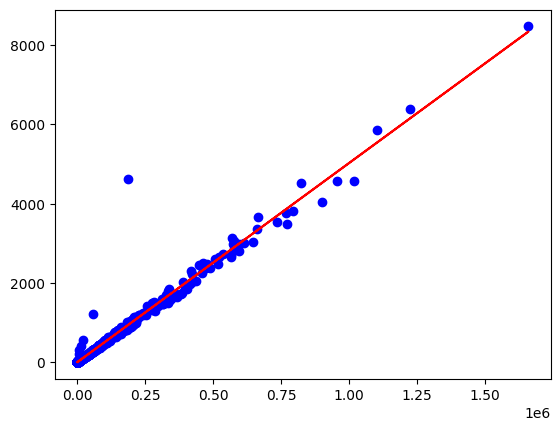

In [70]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, model_1.predict(X_test), color='red')


plt.show()



In [71]:
input_data = {
    'Dollars': [18500, 9000]
}

df_input = pd.DataFrame(input_data)

model_1.predict(df_input)


array([97.78868161, 50.14455838])